1. Import Libraries

In [24]:
import matplotlib.pyplot as plt
import numpy as np  
import os
import random

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn   
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models

2. Device Configuration

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


3. Dataset Paths

In [26]:
data_dir = "chest_xray"

train_dir = os.path.join(data_dir, "train") 
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")

4. Transform

In [27]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

5. Load Dataset

In [28]:
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms) 
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes
print(f"Classes: {class_names}")

Classes: ['NORMAL', 'PNEUMONIA']


6. Show Random 6 images


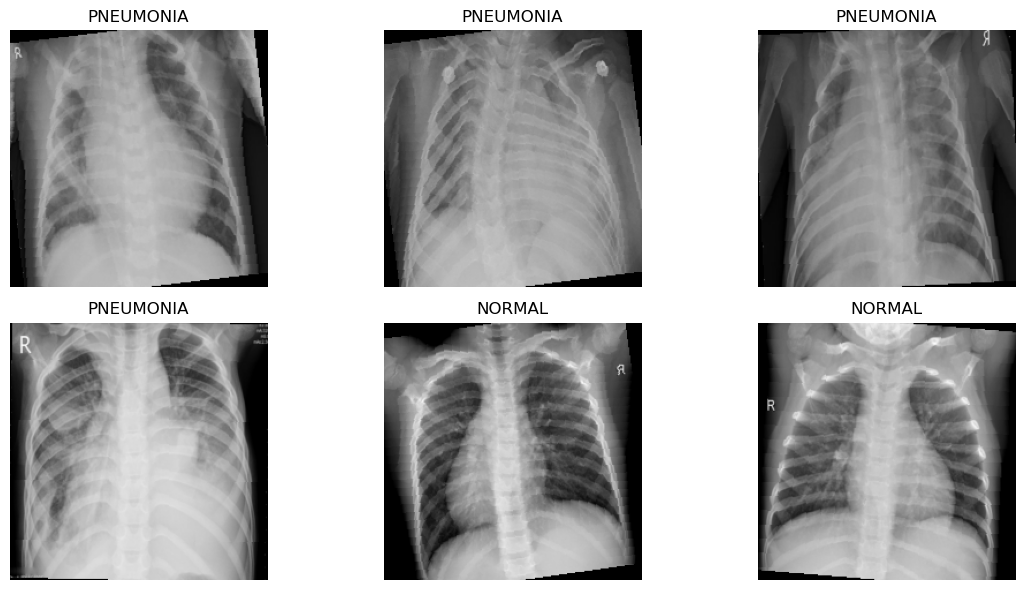

In [29]:
def show_sample_images(data_loader, class_names, num_images=6):
    images, labels = next(iter(data_loader))
    images = images[:num_images]
    labels = labels[:num_images]
    
    plt.figure(figsize=(12, 6))

    for i in range(num_images):
        plt.subplot(2, 3, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

show_sample_images(train_loader, class_names)


7. Load EfficientNet-B0

In [30]:
model = models.efficientnet_b0(pretrained=True)

c:\Users\ASUS\miniconda3\envs\pneumonia-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\pneumonia-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


8. Freeze Layers

In [31]:
for param in model.parameters():
    param.requires_grad = False

9. Modify Classifier

In [32]:
model.add_module("classifier", nn.Linear(model.classifier[1].in_features, len(class_names)))
model = model.to(device)

10. Loss & Optimizer

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

11. Training Loop + Metrics

In [34]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / total
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= val_total
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch 1/5 - Train Loss: 0.2559, Train Acc: 0.8997 - Val Loss: 0.2109, Val Acc: 0.9375
Epoch 2/5 - Train Loss: 0.1700, Train Acc: 0.9367 - Val Loss: 0.1788, Val Acc: 0.9375
Epoch 3/5 - Train Loss: 0.1577, Train Acc: 0.9404 - Val Loss: 0.1478, Val Acc: 0.9375
Epoch 4/5 - Train Loss: 0.1546, Train Acc: 0.9408 - Val Loss: 0.1296, Val Acc: 0.9375
Epoch 5/5 - Train Loss: 0.1417, Train Acc: 0.9473 - Val Loss: 0.1414, Val Acc: 1.0000


12. Plot Loss

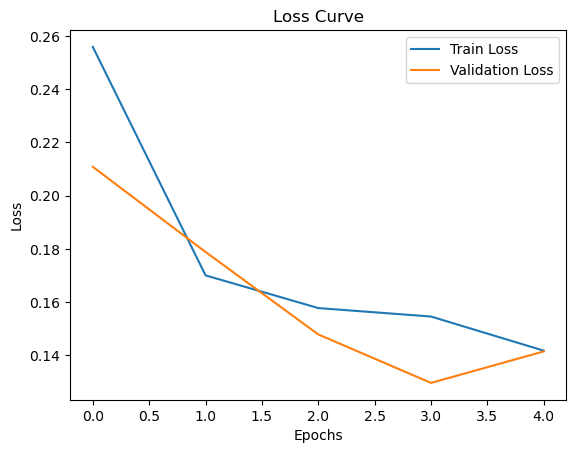

In [35]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

13. Plot Accuracy

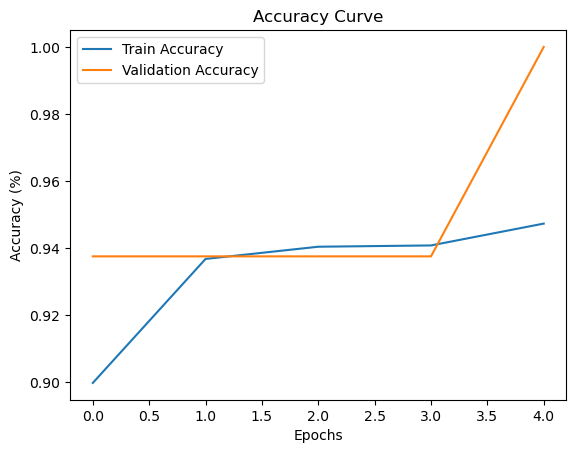

In [36]:
plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

14. Test Prediction

In [37]:
y_true, y_pred = [], []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

15. Confution Matrix

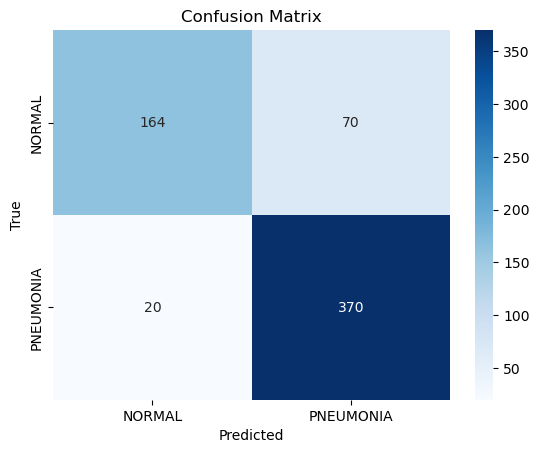

In [38]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=class_names, 
             yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')  
plt.title('Confusion Matrix')
plt.show()

16. Classification Report

In [39]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.70      0.78       234
   PNEUMONIA       0.84      0.95      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.82      0.84       624
weighted avg       0.86      0.86      0.85       624



17. Save Model

In [40]:
torch.save(model.state_dict(), "pneumonia_classifier.pth")